# Consumo historico por agente

Este notebook usa la metrica XM `DemaCome` con entidad `Agente` para identificar los actores con mayor demanda comercial y graficar su comportamiento historico.

In [2]:
from pathlib import Path
import subprocess
import sys
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == 'casos_uso_analitica':
    ROOT = ROOT.parents[1]

OUTPUT_DIR = ROOT / 'outputs' / 'consumo_actores'
OUTPUT_DIR

WindowsPath('e:/proyectos/ProyectosModelosMinisterio/API_XM/outputs/consumo_actores')

## Generar datos

Ajusta las fechas si quieres ampliar o reducir el historico. Si los archivos ya existen, puedes saltar esta celda.

In [2]:
cmd = [
    sys.executable,
    str(ROOT / 'models' / 'consumo_actores.py'),
    '--start-date', '2022-01-01',
    '--end-date', '2024-12-31',
    '--top-n', '20',
    '--output-dir', str(OUTPUT_DIR),
]
subprocess.run(cmd, check=True)

CompletedProcess(args=['c:\\Users\\PC\\AppData\\Local\\Programs\\Python\\Python312\\python.exe', 'e:\\proyectos\\ProyectosModelosMinisterio\\API_XM\\models\\consumo_actores.py', '--start-date', '2022-01-01', '--end-date', '2024-12-31', '--top-n', '20', '--output-dir', 'e:\\proyectos\\ProyectosModelosMinisterio\\API_XM\\outputs\\consumo_actores'], returncode=0)

## Cargar archivos

In [3]:
hourly = pd.read_csv(OUTPUT_DIR / 'consumo_hourly.csv', parse_dates=['datetime', 'month'])
ranking = pd.read_csv(OUTPUT_DIR / 'top_consumidores.csv')
monthly = pd.read_csv(OUTPUT_DIR / 'consumo_mensual_top.csv', parse_dates=['month'])
heatmap = pd.read_csv(OUTPUT_DIR / 'heatmap_top.csv')

ranking.head(10)

,agent_code,agent_name,total_demand_kwh,avg_hourly_demand_kwh,max_hourly_demand_kwh,records,share_percent
0,ENDC,ENEL COLOMBIA SA ESP,4.376615e+10,1.663859e+06,2275235.34,26304,18.115880
1,EPMC,EMPRESAS PUBLICAS DE MEDELLIN E.S.P.,3.640184e+10,1.383890e+06,1810831.70,26304,15.067612
2,CMMC,CARIBEMAR DE LA COSTA S.A.S. E.S.P.,2.650163e+10,1.007513e+06,1394257.34,26304,10.969673
3,CSSC,AIR- E S.A.S. E.S.P.,2.351665e+10,9.937732e+05,1411258.14,23664,9.734116
4,EPSC,CELSIA COLOMBIA S.A. E.S.P.,1.240752e+10,4.716972e+05,744628.48,26304,5.135777
5,ISGC,ISAGEN S.A. E.S.P.,1.213932e+10,4.615010e+05,563961.53,26304,5.024763
6,EMIC,EMPRESAS MUNICIPALES DE CALI E.I.C.E. E.S.P.,9.663955e+09,3.673949e+05,544712.09,26304,4.000147
7,GECC,GENERADORA Y COMERCIALIZADORA DE ENERGIA DEL C...,7.924240e+09,3.012561e+05,490951.06,26304,3.280037
8,ESSC,ELECTRIFICADORA DE SANTANDER S.A. E.S.P.,7.066890e+09,2.686622e+05,386522.23,26304,2.925159
9,CNSC,CENTRALES ELECTRICAS DEL NORTE DE SANTANDER S....,5.155222e+09,1.959863e+05,280026.70,26304,2.133873


## Top consumidores historicos

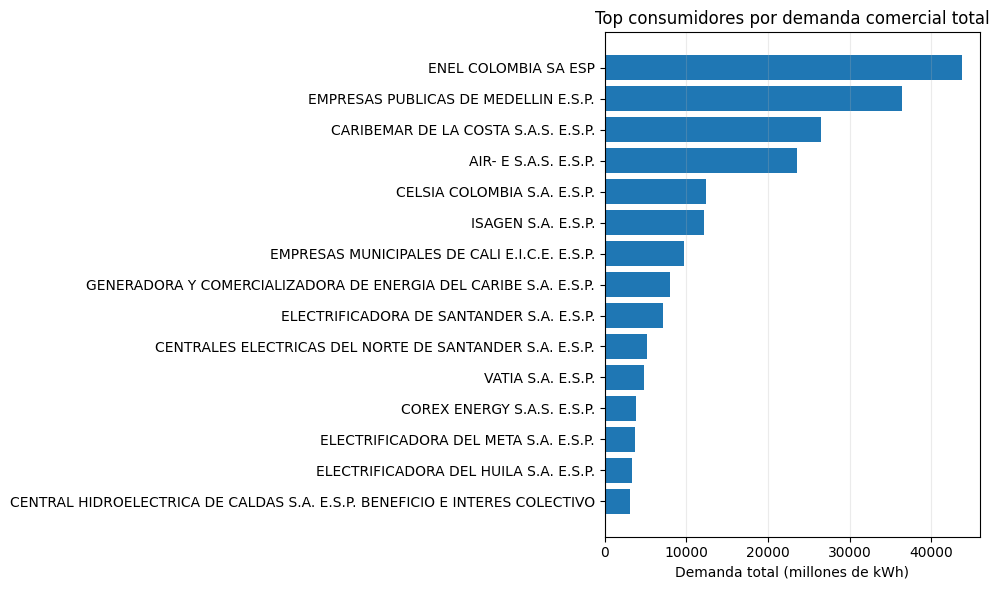

In [4]:
top = ranking.head(15).sort_values('total_demand_kwh')

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top['agent_name'], top['total_demand_kwh'] / 1_000_000)
ax.set_title('Top consumidores por demanda comercial total')
ax.set_xlabel('Demanda total (millones de kWh)')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()

## Participacion acumulada

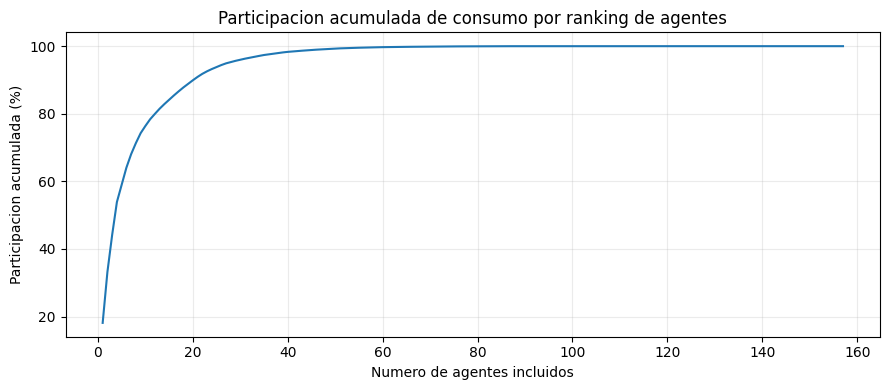

In [5]:
ranked = ranking.copy()
ranked['cum_share_percent'] = ranked['share_percent'].cumsum()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(ranked) + 1), ranked['cum_share_percent'])
ax.set_title('Participacion acumulada de consumo por ranking de agentes')
ax.set_xlabel('Numero de agentes incluidos')
ax.set_ylabel('Participacion acumulada (%)')
ax.grid(alpha=0.25)
plt.tight_layout()

## Evolucion mensual de los principales agentes

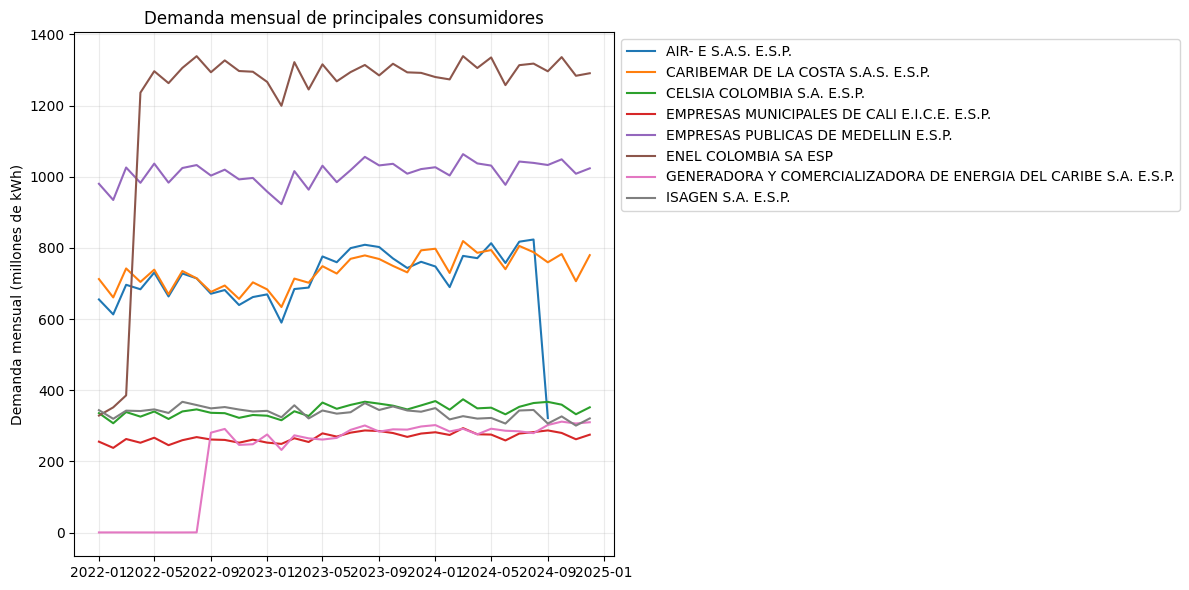

In [6]:
top_codes = ranking.head(8)['agent_code']
plot_monthly = monthly[monthly['agent_code'].isin(top_codes)]

fig, ax = plt.subplots(figsize=(12, 6))
for name, group in plot_monthly.groupby('agent_name'):
    ax.plot(group['month'], group['demanda_comercial_kwh'] / 1_000_000, label=name)
ax.set_title('Demanda mensual de principales consumidores')
ax.set_ylabel('Demanda mensual (millones de kWh)')
ax.grid(alpha=0.25)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()

## Patron horario agregado

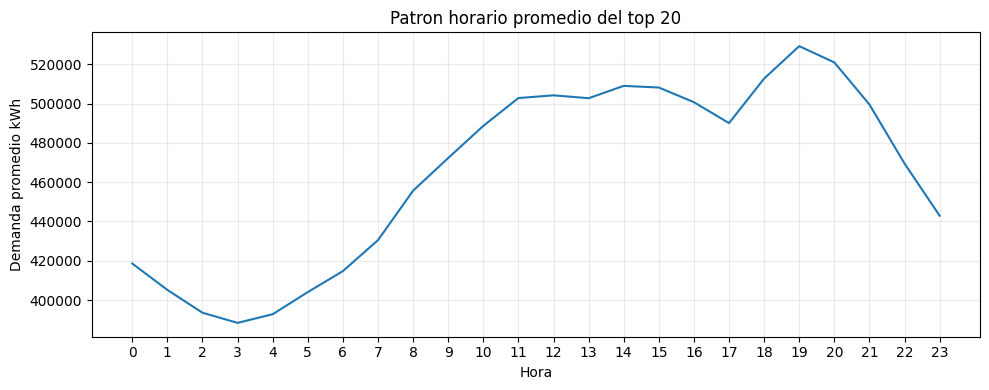

In [4]:
hourly_pattern = (
    hourly[hourly['agent_code'].isin(ranking.head(20)['agent_code'])]
    .groupby('hour', as_index=False)['demanda_comercial_kwh']
    .mean()
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hourly_pattern['hour'], hourly_pattern['demanda_comercial_kwh'])
ax.set_title('Patron horario promedio del top 20')
ax.set_xlabel('Hora')
ax.set_ylabel('Demanda promedio kWh')
ax.set_xticks(range(24))
ax.grid(alpha=0.25)
plt.tight_layout()

## Mapa de calor de consumo

Selecciona un agente del ranking para ver su consumo promedio por dia de semana y hora.

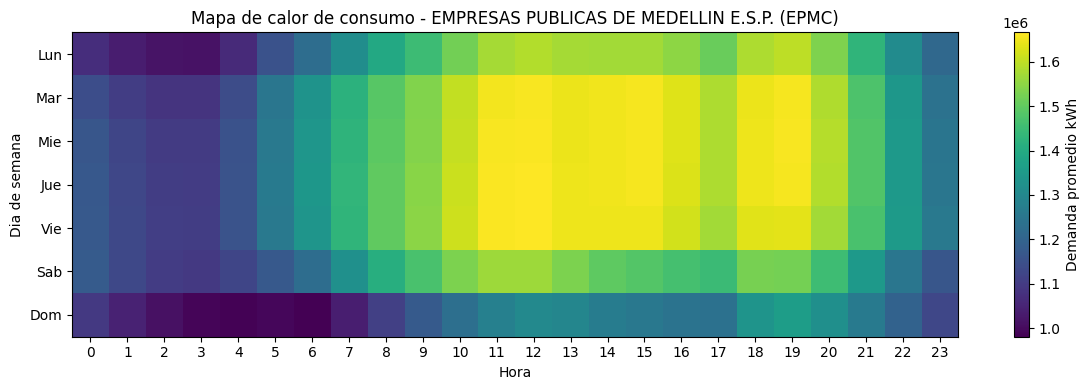

In [5]:
agent_code = ranking.iloc[1]['agent_code']
agent_name = ranking.iloc[1]['agent_name']
agent_heatmap = heatmap[heatmap['agent_code'] == agent_code]
pivot = agent_heatmap.pivot(index='dayofweek', columns='hour', values='demanda_comercial_kwh')

fig, ax = plt.subplots(figsize=(12, 4))
image = ax.imshow(pivot.values, aspect='auto', cmap='viridis')
ax.set_title(f'Mapa de calor de consumo - {agent_name} ({agent_code})')
ax.set_xlabel('Hora')
ax.set_ylabel('Dia de semana')
ax.set_xticks(range(24))
ax.set_yticks(range(7))
ax.set_yticklabels(['Lun', 'Mar', 'Mie', 'Jue', 'Vie', 'Sab', 'Dom'])
fig.colorbar(image, ax=ax, label='Demanda promedio kWh')
plt.tight_layout()